In [1]:
# Cell 1: Imports & Parameter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_final\icvar_dd_ppo_S1_final\ppo_icvar_dd_state1_cpcv_20251223_154013\E2")
paths = [f"Path_{i:02d}" for i in range(1, 6)]

def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


In [8]:
df_btc = load_and_info(run_dir / "Path_01/rewards.parquet")
display(df_btc.head(), df_btc.tail())


--- rewards.parquet ---
Shape: (1505, 18)
Columns: 18


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
0,1,2015-01-05 00:00:00+00:00,1.000001e+06,1.000000e+06,8.333330e-07,NaN,NaN,NaN,0.0,0.0,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1,2,2015-01-06 00:00:00+00:00,1.000002e+06,1.000001e+06,8.333330e-07,NaN,NaN,NaN,0.0,0.0,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
2,3,2015-01-07 00:00:00+00:00,1.000003e+06,1.000002e+06,8.333330e-07,NaN,NaN,NaN,0.0,0.0,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
3,4,2015-01-08 00:00:00+00:00,1.000003e+06,1.000003e+06,8.333330e-07,NaN,NaN,NaN,0.0,0.0,8.333330e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
4,5,2015-01-09 00:00:00+00:00,1.000004e+06,1.000003e+06,5.555554e-07,NaN,NaN,NaN,0.0,0.0,5.555554e-07,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1


,round,t,nav_t,nav_t-1,r_log_t,var_t,cvar_t,cvar_tminus1,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
1500,1506,2020-12-24 00:00:00+00:00,2.463754e+06,2.415055e+06,0.019964,0.047740,0.114135,0.114459,-0.000324,0.0,0.020288,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1501,1507,2020-12-28 00:00:00+00:00,2.809005e+06,2.463754e+06,0.131144,0.047668,0.113811,0.114135,-0.000324,0.0,0.131468,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1502,1508,2020-12-29 00:00:00+00:00,2.840270e+06,2.809005e+06,0.011069,0.047596,0.113486,0.113811,-0.000325,0.0,0.011394,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1503,1509,2020-12-30 00:00:00+00:00,2.994141e+06,2.840270e+06,0.052758,0.047524,0.113161,0.113486,-0.000325,0.0,0.053083,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1
1504,1510,2020-12-31 00:00:00+00:00,3.003941e+06,2.994141e+06,0.003268,0.047452,0.112837,0.113161,-0.000324,0.0,0.003592,icvar_dd,ex_ante,0.05,1.0,1.0,rolling,0.1


In [9]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"
    f_trade   = p / "trade_events.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    elif f_trade.is_file():
        df = load_parquet(f_trade)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()



Path_01
Path_02
Path_03
Path_04
Path_05


AttributeError: 'WindowsPath' object has no attribute 'head'

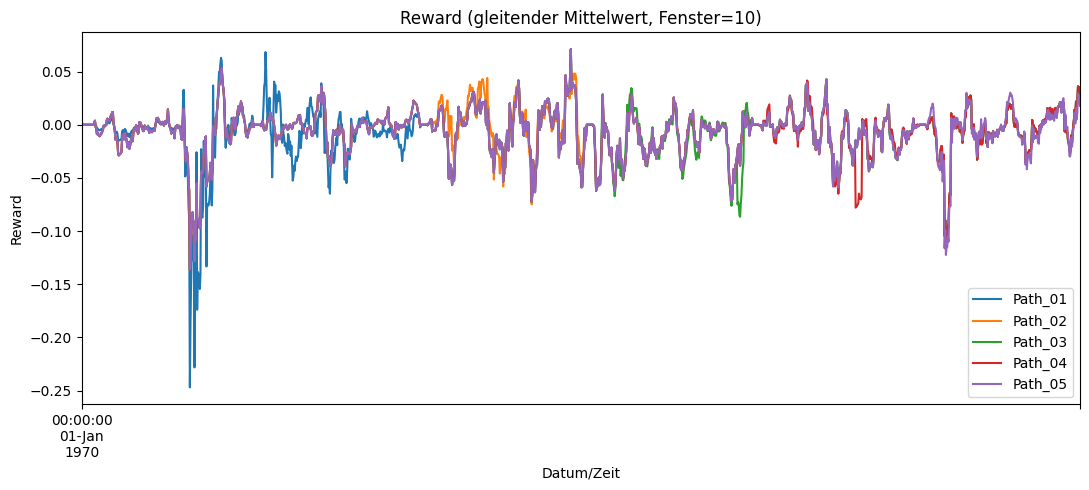

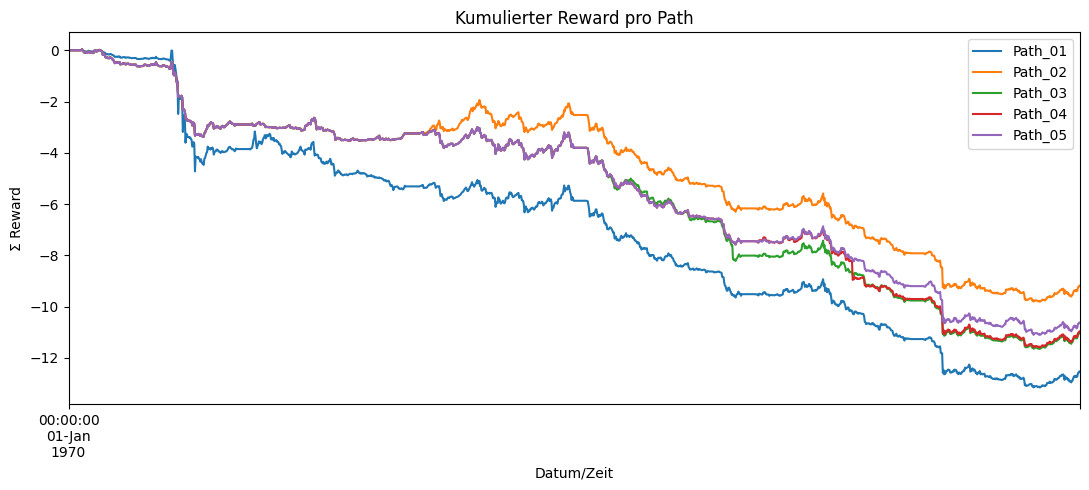

In [4]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [5]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


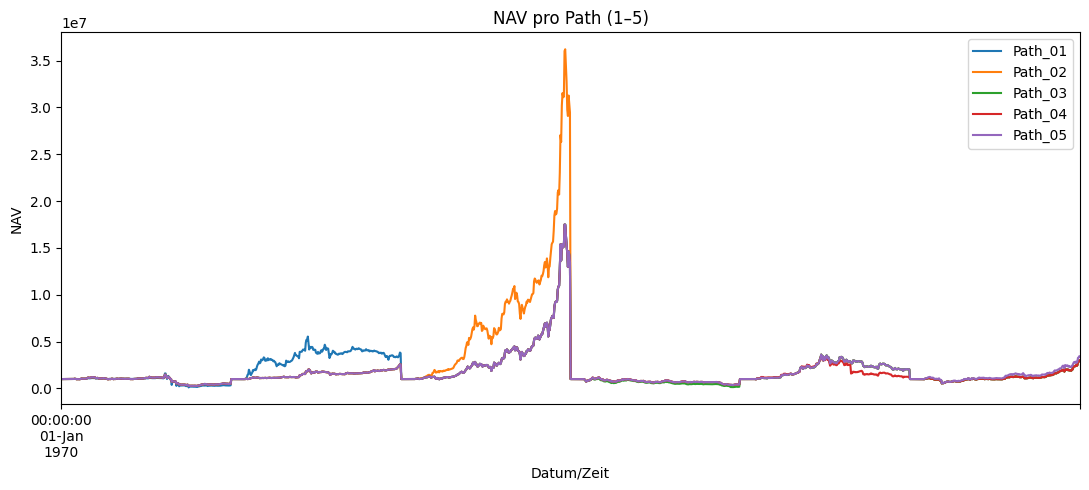

In [6]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

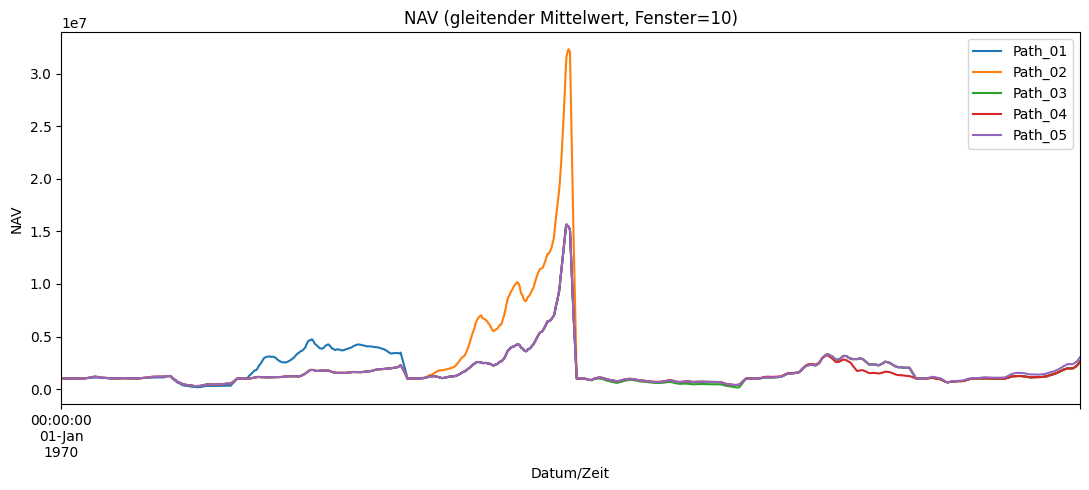

In [7]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()


In [10]:
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_trade   = p / "trade_events.parquet"


    if f_trade.is_file():
        df = load_parquet(f_trade)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")
df_btc = load_and_info(f_trade)
display(df_btc)



Path_01
⚠️ Keine Reward-Spalte in Path_01
Path_02
⚠️ Keine Reward-Spalte in Path_02
Path_03
⚠️ Keine Reward-Spalte in Path_03
Path_04
⚠️ Keine Reward-Spalte in Path_04
Path_05
⚠️ Keine Reward-Spalte in Path_05


In [13]:
df_btc = load_and_info(f_trade)
display(df_btc)


--- trade_events.parquet ---
Shape: (89, 11)
Columns: 11


,asset,q,adj_open,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t
0,BTC-USD,1272.337356,218.039993,218.367053,277836.559270,416.130647,694.591398,0.0,694.591398,20,2015-02-02 00:00:00+00:00
1,BTC-USD,1335.498407,226.929993,227.270388,303519.240797,454.596970,758.798102,0.0,758.798102,21,2015-02-03 00:00:00+00:00
2,BTC-USD,252.834180,238.380005,238.737575,60361.019100,90.405921,150.902548,0.0,150.902548,22,2015-02-04 00:00:00+00:00
3,BTC-USD,-228.480121,288.888885,288.455552,65906.359487,99.008052,164.765899,0.0,164.765899,132,2015-07-14 00:00:00+00:00
4,BTC-USD,115.013619,266.219330,266.618659,30664.776820,45.928273,76.661942,0.0,76.661942,152,2015-08-11 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
84,BTC-USD,4.552106,11922.666016,11940.550015,54354.646842,81.409856,135.886617,0.0,135.886617,1427,2020-09-02 00:00:00+00:00
85,ETH-USD,152.530350,337.454041,337.960222,51549.191019,77.207975,128.872978,0.0,128.872978,1431,2020-09-09 00:00:00+00:00
86,ETH-USD,108.077332,403.655792,404.261276,43691.480302,65.439062,109.228701,0.0,109.228701,1466,2020-10-28 00:00:00+00:00
87,ETH-USD,-102.779871,610.004822,609.089815,62602.172332,94.044326,156.505431,0.0,156.505431,1485,2020-11-24 00:00:00+00:00
